# SmartCare Hospital AI Coursework
## Task 04 — Exploratory Data Analysis

**Objective:** Use clear summaries and visualisations to understand the corrected 875 × 25 dataset and identify non-causal patterns related to no-show behaviour.

## 4.1 Load Data and Review Quality

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Run Colab/VS Code from the cloned repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models_checkpoints'

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_DIR / 'smartcare_preprocessed_unscaled.csv')
assert df.shape == (875, 25)

print('Dataset shape:', df.shape)
print('Missing values:', int(df.isnull().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
display(df.head())

Dataset shape: (875, 25)
Missing values: 0
Duplicate rows: 0


,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,no_show,appointment_month,appointment_dayofweek,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,missed_ratio,has_missed_before
0,53,10,1,0,1,0,4,3,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.000000,0
1,26,2,3,1,0,0,5,3,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.333333,1
2,22,22,7,1,1,1,7,2,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0.142857,1
3,44,16,1,0,0,0,10,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0
4,50,43,1,0,0,1,10,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0.000000,0


## 4.2 Descriptive Statistics and Class Balance

,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,missed_ratio,no_show
count,875.00,875.00,875.00,875.00,875.00,875.00,875.00
mean,44.78,22.00,2.86,0.57,0.85,0.19,0.57
std,17.71,13.12,1.68,0.75,0.95,0.27,0.50
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,33.50,10.00,2.00,0.00,0.00,0.00,0.00
50%,45.00,22.00,3.00,0.00,1.00,0.00,1.00
75%,57.00,34.00,4.00,1.00,1.00,0.33,1.00
max,90.00,44.00,10.00,4.00,5.00,1.00,1.00


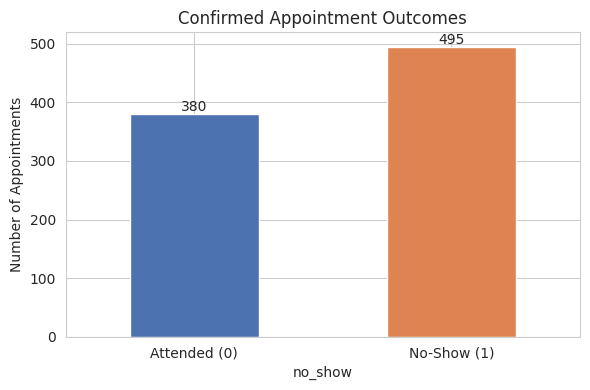

In [2]:
summary_columns = [
    'age', 'waiting_days', 'previous_appointments',
    'missed_previous_appointments', 'previous_admissions',
    'missed_ratio', 'no_show'
]
display(df[summary_columns].describe().round(2))

counts = df['no_show'].value_counts().sort_index()
ax = counts.plot(kind='bar', color=['#4C72B0', '#DD8452'], figsize=(6, 4))
ax.set_xticklabels(['Attended (0)', 'No-Show (1)'], rotation=0)
ax.set_title('Confirmed Appointment Outcomes')
ax.set_ylabel('Number of Appointments')
for position, value in enumerate(counts):
    ax.text(position, value + 5, str(value), ha='center')
plt.tight_layout()
plt.show()

**Insight:** The corrected data contains 380 attended appointments and 495 no-shows. The moderate imbalance means that accuracy should be reported with precision, recall, F1-score, and ROC-AUC.

## 4.3 Numerical Distributions

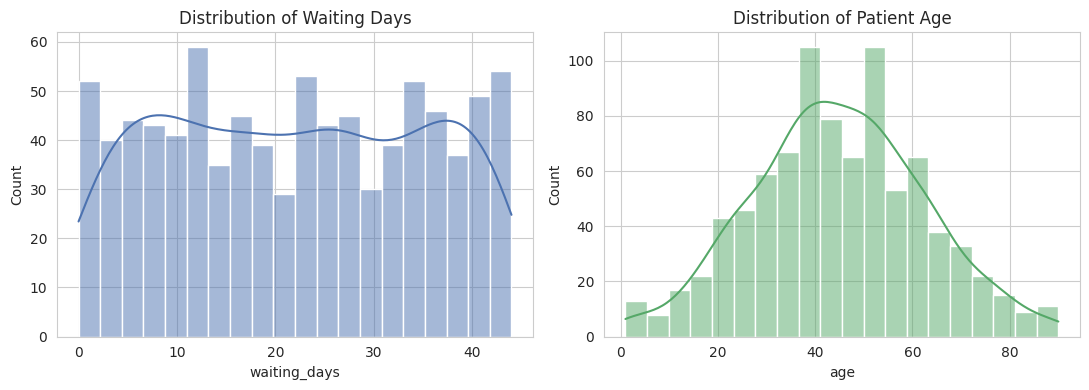

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['waiting_days'], bins=20, kde=True, color='#4C72B0', ax=axes[0])
axes[0].set_title('Distribution of Waiting Days')
sns.histplot(df['age'], bins=20, kde=True, color='#55A868', ax=axes[1])
axes[1].set_title('Distribution of Patient Age')
plt.tight_layout()
plt.show()

## 4.4 Outcome Group Comparison

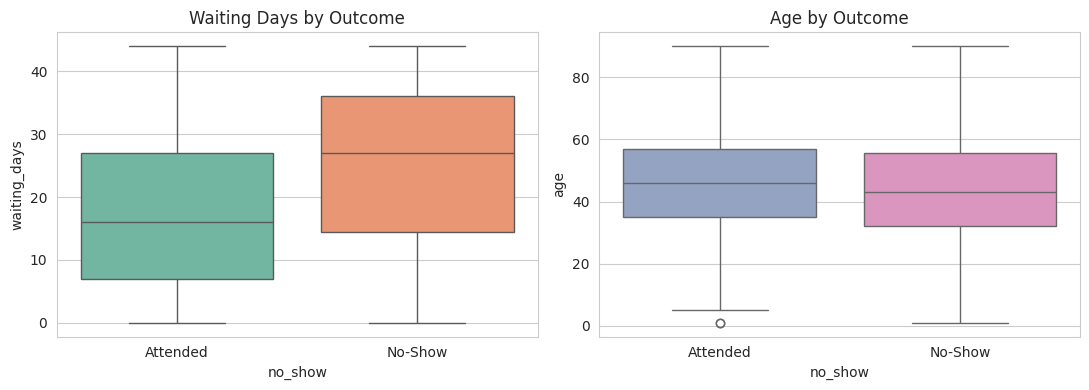

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='no_show', y='waiting_days', hue='no_show',
            palette=['#66C2A5', '#FC8D62'], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1], ['Attended', 'No-Show'])
axes[0].set_title('Waiting Days by Outcome')

sns.boxplot(data=df, x='no_show', y='age', hue='no_show',
            palette=['#8DA0CB', '#E78AC3'], legend=False, ax=axes[1])
axes[1].set_xticks([0, 1], ['Attended', 'No-Show'])
axes[1].set_title('Age by Outcome')
plt.tight_layout()
plt.show()

**Insight:** Waiting time shows more outcome separation than age. The strong overlap confirms that neither variable should be interpreted as a complete explanation by itself.

## 4.5 Correlation Analysis

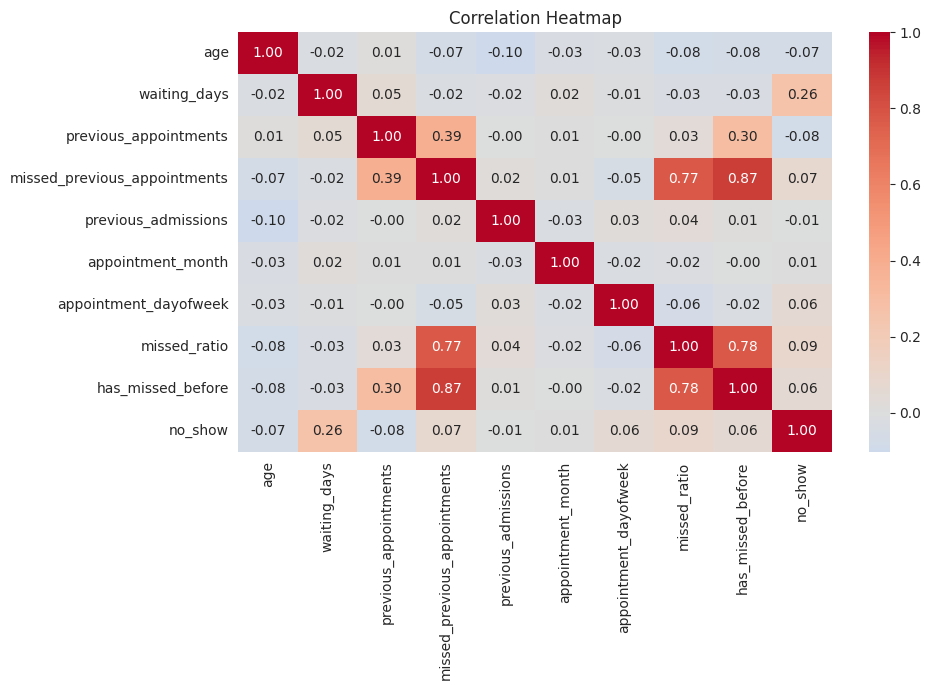

In [5]:
corr_columns = [
    'age', 'waiting_days', 'previous_appointments',
    'missed_previous_appointments', 'previous_admissions',
    'appointment_month', 'appointment_dayofweek',
    'missed_ratio', 'has_missed_before', 'no_show'
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_columns].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:** Most individual linear relationships are weak. Correlation shows association, not causation, and model usefulness must be tested using cross-validation.

## 4.6 Weekday and Department Patterns

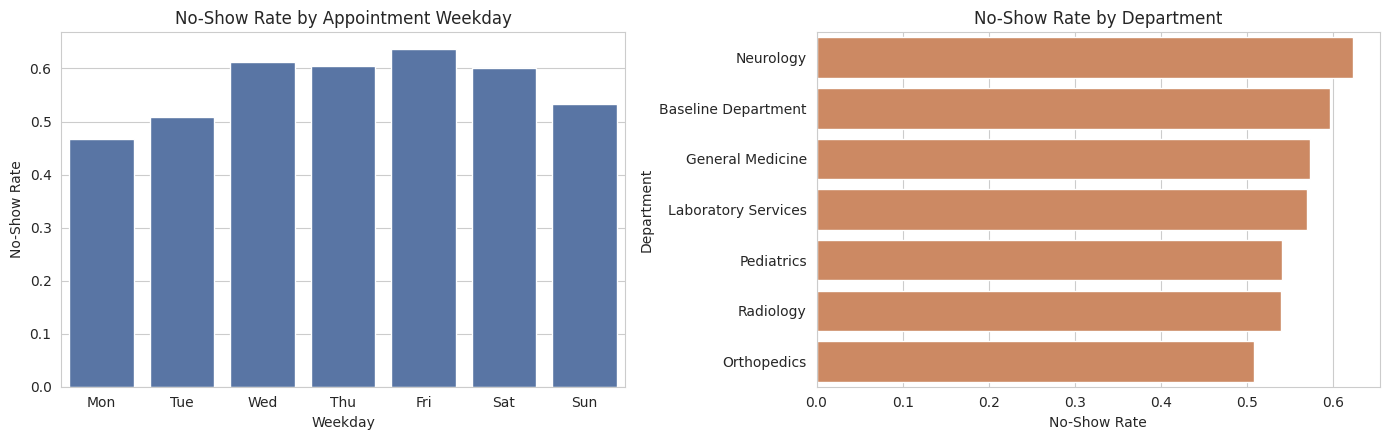

,appointment_dayofweek,count,mean,Weekday
0,0,124,0.468,Mon
1,1,130,0.508,Tue
2,2,121,0.612,Wed
3,3,129,0.605,Thu
4,4,121,0.636,Fri
5,5,128,0.602,Sat
6,6,122,0.533,Sun


,Department,count,mean
3,Neurology,130,0.623
0,Baseline Department,141,0.596
1,General Medicine,136,0.574
2,Laboratory Services,100,0.570
5,Pediatrics,122,0.541
6,Radiology,128,0.539
4,Orthopedics,118,0.508


In [6]:
weekday_rates = (df.groupby('appointment_dayofweek')['no_show']
                 .agg(['count', 'mean']).reset_index())
weekday_rates['Weekday'] = weekday_rates['appointment_dayofweek'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
})

department_columns = [
    column for column in df.columns if column.startswith('department_')
]
department_label = pd.Series('Baseline Department', index=df.index)
for column in department_columns:
    department_label[df[column].eq(1)] = column.replace('department_', '')
department_rates = (df.assign(Department=department_label)
                    .groupby('Department')['no_show']
                    .agg(['count', 'mean']).reset_index()
                    .sort_values('mean', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=weekday_rates, x='Weekday', y='mean', color='#4C72B0', ax=axes[0])
axes[0].set_title('No-Show Rate by Appointment Weekday')
axes[0].set_ylabel('No-Show Rate')

sns.barplot(data=department_rates, x='mean', y='Department', color='#DD8452', ax=axes[1])
axes[1].set_title('No-Show Rate by Department')
axes[1].set_xlabel('No-Show Rate')
plt.tight_layout()
plt.show()

display(weekday_rates.round(3))
display(department_rates.round(3))

## 4.7 Attendance-History and Waiting Patterns

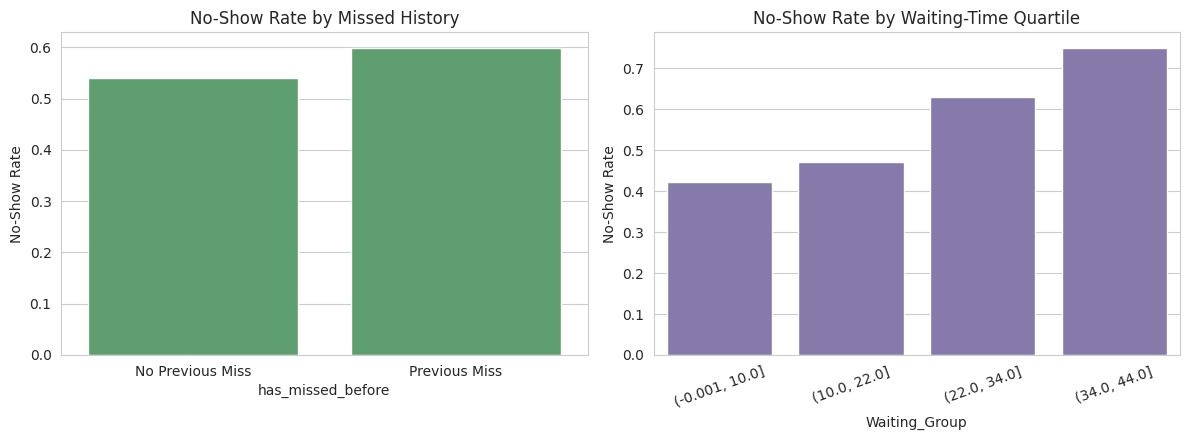

,has_missed_before,count,mean
0,0,493,0.540
1,1,382,0.599


,Waiting_Group,count,mean
0,"(-0.001, 10.0]",220,0.423
1,"(10.0, 22.0]",229,0.472
2,"(22.0, 34.0]",214,0.631
3,"(34.0, 44.0]",212,0.750


In [7]:
history_rates = (df.groupby('has_missed_before')['no_show']
                 .agg(['count', 'mean']).reset_index())
waiting_group = pd.qcut(df['waiting_days'], q=4, duplicates='drop')
waiting_rates = (df.assign(Waiting_Group=waiting_group)
                 .groupby('Waiting_Group', observed=True)['no_show']
                 .agg(['count', 'mean']).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=history_rates, x='has_missed_before', y='mean',
            color='#55A868', ax=axes[0])
axes[0].set_xticks([0, 1], ['No Previous Miss', 'Previous Miss'])
axes[0].set_title('No-Show Rate by Missed History')
axes[0].set_ylabel('No-Show Rate')

sns.barplot(data=waiting_rates, x='Waiting_Group', y='mean',
            color='#8172B2', ax=axes[1])
axes[1].set_title('No-Show Rate by Waiting-Time Quartile')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('No-Show Rate')
plt.tight_layout()
plt.show()

display(history_rates.round(3))
display(waiting_rates.round(3))

### Task 04 Summary

- The corrected dataset contains 875 rows and 25 columns with no missing values.
- The target is moderately imbalanced.
- Waiting time and earlier attendance history show useful descriptive patterns.
- Weekday and department rates vary, but these differences do not prove causation.
- The compact feature set is suitable for leakage-safe model comparison in Task 05.